In [2]:
import pandas as pd

df = pd.read_csv('/content/heart_disease_risk_dataset_earlymed.csv')

print("Dataset loaded successfully")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully
Shape: (70000, 19)


,Chest_Pain,Shortness_of_Breath,Fatigue,Palpitations,Dizziness,Swelling,Pain_Arms_Jaw_Back,Cold_Sweats_Nausea,High_BP,High_Cholesterol,Diabetes,Smoking,Obesity,Sedentary_Lifestyle,Family_History,Chronic_Stress,Gender,Age,Heart_Risk
0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,48.0,0.0
1,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,46.0,0.0
2,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,66.0,0.0
3,1.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,60.0,1.0
4,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,69.0,0.0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Chest_Pain           70000 non-null  float64
 1   Shortness_of_Breath  70000 non-null  float64
 2   Fatigue              70000 non-null  float64
 3   Palpitations         70000 non-null  float64
 4   Dizziness            70000 non-null  float64
 5   Swelling             70000 non-null  float64
 6   Pain_Arms_Jaw_Back   70000 non-null  float64
 7   Cold_Sweats_Nausea   70000 non-null  float64
 8   High_BP              70000 non-null  float64
 9   High_Cholesterol     70000 non-null  float64
 10  Diabetes             70000 non-null  float64
 11  Smoking              70000 non-null  float64
 12  Obesity              70000 non-null  float64
 13  Sedentary_Lifestyle  70000 non-null  float64
 14  Family_History       70000 non-null  float64
 15  Chronic_Stress       70000 non-null 

In [4]:
df.isnull().sum()

,0
Chest_Pain,0
Shortness_of_Breath,0
Fatigue,0
Palpitations,0
Dizziness,0
Swelling,0
Pain_Arms_Jaw_Back,0
Cold_Sweats_Nausea,0
High_BP,0
High_Cholesterol,0


In [5]:
df['Heart_Risk'].value_counts()

,count
Heart_Risk,
0.0,35000
1.0,35000


In [7]:
X = df.drop('Heart_Risk', axis=1)
y = df['Heart_Risk']

In [8]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (70000, 18)
y shape: (70000,)


In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 56000
Testing samples: 14000


In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling completed")

Scaling completed


In [12]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(X_train_scaled, y_train)

logistic_predictions = logistic_model.predict(X_test_scaled)

print("Logistic Regression completed")

Logistic Regression completed


In [14]:
from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(
    random_state=42
)

tree_model.fit(X_train, y_train)

tree_predictions = tree_model.predict(X_test)

print("Decision Tree completed")

Decision Tree completed


In [15]:
from sklearn.ensemble import RandomForestClassifier

forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

forest_model.fit(X_train, y_train)

forest_predictions = forest_model.predict(X_test)

print("Random Forest completed")

Random Forest completed


In [17]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [18]:
def evaluate_model(y_true, y_pred):

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    return accuracy, precision, recall, f1

In [19]:
logistic_results = evaluate_model(
    y_test,
    logistic_predictions
)

tree_results = evaluate_model(
    y_test,
    tree_predictions
)

forest_results = evaluate_model(
    y_test,
    forest_predictions
)

In [20]:
results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest'
    ],

    'Accuracy': [
        logistic_results[0],
        tree_results[0],
        forest_results[0]
    ],

    'Precision': [
        logistic_results[1],
        tree_results[1],
        forest_results[1]
    ],

    'Recall': [
        logistic_results[2],
        tree_results[2],
        forest_results[2]
    ],

    'F1-score': [
        logistic_results[3],
        tree_results[3],
        forest_results[3]
    ]
})

results.round(4)

,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.9911,0.9914,0.9909,0.9911
1,Decision Tree,0.9818,0.9813,0.9823,0.9818
2,Random Forest,0.9916,0.9924,0.9909,0.9916


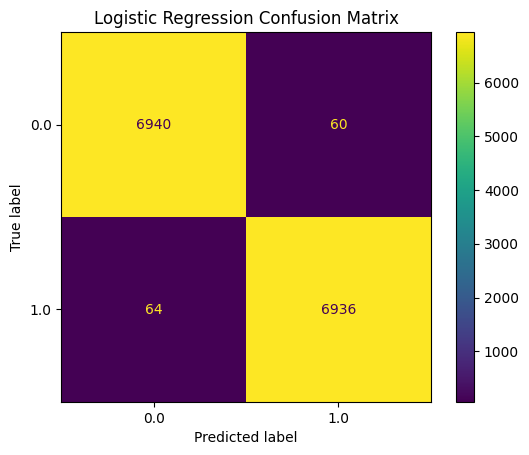

In [22]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    logistic_predictions
)

plt.title("Logistic Regression Confusion Matrix")
plt.show()

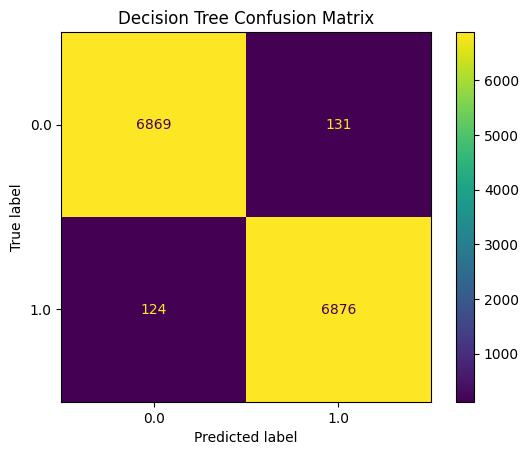

In [23]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    tree_predictions
)

plt.title("Decision Tree Confusion Matrix")
plt.show()

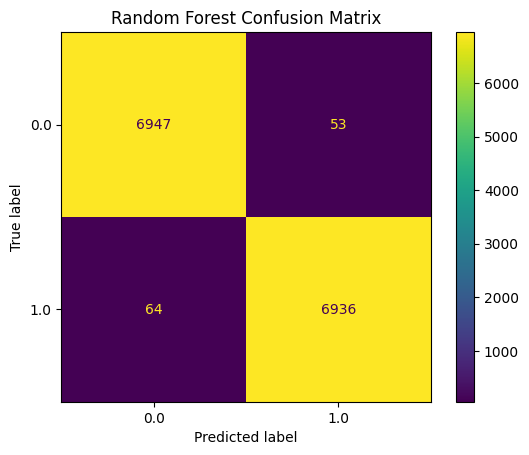

In [24]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    forest_predictions
)

plt.title("Random Forest Confusion Matrix")
plt.show()

In [25]:
logistic_prob = logistic_model.predict_proba(
    X_test_scaled
)[:, 1]

tree_prob = tree_model.predict_proba(
    X_test
)[:, 1]

forest_prob = forest_model.predict_proba(
    X_test
)[:, 1]

In [26]:
from sklearn.metrics import roc_auc_score

logistic_auc = roc_auc_score(
    y_test,
    logistic_prob
)

tree_auc = roc_auc_score(
    y_test,
    tree_prob
)

forest_auc = roc_auc_score(
    y_test,
    forest_prob
)

print("Logistic Regression ROC-AUC:",
      round(logistic_auc, 4))

print("Decision Tree ROC-AUC:",
      round(tree_auc, 4))

print("Random Forest ROC-AUC:",
      round(forest_auc, 4))

Logistic Regression ROC-AUC: 0.9995
Decision Tree ROC-AUC: 0.9818
Random Forest ROC-AUC: 0.9995


In [27]:
results['ROC-AUC'] = [
    logistic_auc,
    tree_auc,
    forest_auc
]

results.round(4)

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.9911,0.9914,0.9909,0.9911,0.9995
1,Decision Tree,0.9818,0.9813,0.9823,0.9818,0.9818
2,Random Forest,0.9916,0.9924,0.9909,0.9916,0.9995


In [28]:
best_model = results.loc[
    results['F1-score'].idxmax()
]

print("Best Model:", best_model['Model'])
print("Accuracy:", round(best_model['Accuracy'], 4))
print("Precision:", round(best_model['Precision'], 4))
print("Recall:", round(best_model['Recall'], 4))
print("F1-score:", round(best_model['F1-score'], 4))
print("ROC-AUC:", round(best_model['ROC-AUC'], 4))

Best Model: Random Forest
Accuracy: 0.9916
Precision: 0.9924
Recall: 0.9909
F1-score: 0.9916
ROC-AUC: 0.9995
